# Dubins Path Planning

Aircraft cannot make instantaneous turns — they follow curved trajectories
constrained by their minimum turning radius. A Dubins path is the shortest
path between two oriented waypoints (position + heading) that respects a
minimum turning radius constraint. HyPlan uses Dubins paths to model
realistic aircraft maneuvers between flight lines.

This notebook covers:

1. Creating waypoints with position and heading
2. Computing Dubins paths between waypoint pairs
3. Understanding turn radius from speed and bank angle
4. Visualizing multi-segment routes
5. Inspecting path geometry and length
6. Integration with flight lines
7. Effect of speed and bank angle on path geometry

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from hyplan.dubins_path import Waypoint, DubinsPath
from hyplan.flight_line import FlightLine
from hyplan.geometry import wrap_to_360
from hyplan.units import ureg

## 1. Waypoints

A `Waypoint` defines a position (lat/lon), a heading (degrees from north),
and an optional altitude and name. Waypoints are the inputs to the Dubins
path solver.

In [2]:
# Create waypoints with different headings
wp1 = Waypoint(latitude=34.20, longitude=-118.35, heading=90.0, name="WP1 East")
wp2 = Waypoint(latitude=34.10, longitude=-118.15, heading=270.0, name="WP2 West")
wp3 = Waypoint(latitude=34.20, longitude=-117.95, heading=90.0, name="WP3 East")

print(f"Waypoint 1: {wp1.name}")
print(f"  Position: ({wp1.latitude}, {wp1.longitude})")
print(f"  Heading:  {wp1.heading} deg")
print(f"  Geometry: {wp1.geometry}")
print()

# Waypoints can include altitude
wp_alt = Waypoint(latitude=34.15, longitude=-118.25, heading=180.0,
                  altitude_msl=6000 * ureg.meter, name="WP with altitude")
print(f"{wp_alt.name}: altitude = {wp_alt.altitude_msl}")

# Dictionary representation
print(f"\nDictionary: {wp1.to_dict()}")

Waypoint 1: WP1 East
  Position: (34.2, -118.35)
  Heading:  90.0 deg
  Geometry: POINT (-118.35 34.2)

WP with altitude: altitude = 6000 meter

Dictionary: {'latitude': 34.2, 'longitude': -118.35, 'heading': np.float64(90.0), 'altitude_msl': None, 'name': 'WP1 East'}


## 2. Computing a Dubins Path

A `DubinsPath` connects two waypoints with the shortest feasible path. The turn
radius is determined by the aircraft's speed and bank angle:

$$r = \frac{v^2}{g \cdot \tan(\theta)}$$

where $v$ is speed (m/s), $g$ is gravity (9.8 m/s$^2$), and $\theta$ is bank angle.

Turn radius: 2188 m (1.2 nmi)
Path length: 26399.40760212203 meter
Path points: 265


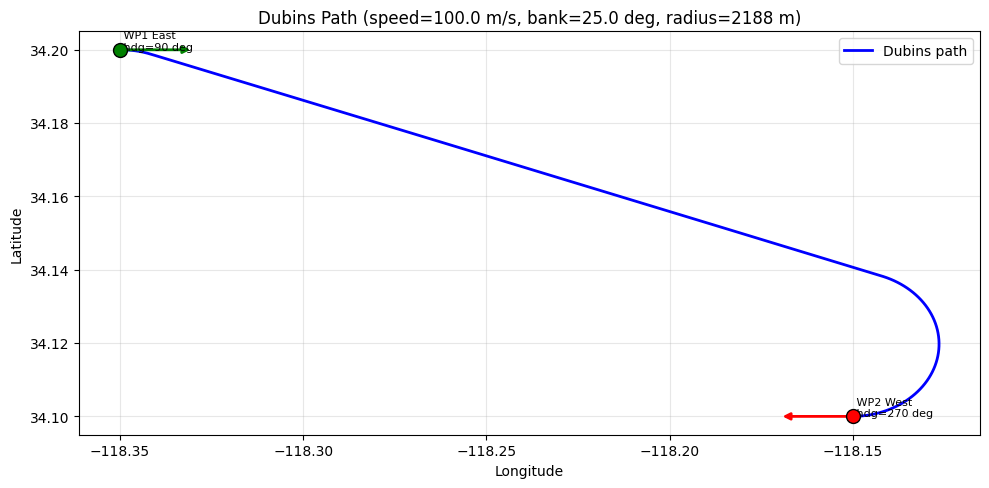

In [3]:
# Compute a Dubins path between two waypoints
speed = 100.0       # m/s (~194 knots, typical for King Air)
bank_angle = 25.0   # degrees (standard rate turn)
step_size = 100.0   # meters (sampling resolution)

path = DubinsPath(
    start=wp1,
    end=wp2,
    speed=speed,
    bank_angle=bank_angle,
    step_size=step_size,
)

# Turn radius
turn_radius = speed**2 / (9.8 * np.tan(np.radians(bank_angle)))
print(f"Turn radius: {turn_radius:.0f} m ({turn_radius / 1852:.1f} nmi)")
print(f"Path length: {path.length}")
print(f"Path points: {len(list(path.geometry.coords))}")

# Visualize
fig, ax = plt.subplots(figsize=(10, 6))
lons, lats = zip(*list(path.geometry.coords))
ax.plot(lons, lats, "b-", linewidth=2, label="Dubins path")

# Mark waypoints with heading arrows
for wp, color in [(wp1, "green"), (wp2, "red")]:
    ax.scatter(wp.longitude, wp.latitude, c=color, s=100, zorder=5, edgecolors="black")
    # Arrow showing heading
    dx = 0.02 * np.sin(np.radians(wp.heading))
    dy = 0.02 * np.cos(np.radians(wp.heading))
    ax.annotate("", xy=(wp.longitude + dx, wp.latitude + dy),
                xytext=(wp.longitude, wp.latitude),
                arrowprops=dict(arrowstyle="-|>", color=color, lw=2))
    ax.annotate(f" {wp.name}\n hdg={wp.heading:.0f} deg",
                (wp.longitude, wp.latitude), fontsize=8)

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title(f"Dubins Path (speed={speed} m/s, bank={bank_angle} deg, radius={turn_radius:.0f} m)")
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_aspect("equal")
plt.tight_layout()
plt.show()

## 3. Multi-Segment Routes

Chain multiple Dubins paths together to model a complete route through
a sequence of waypoints — for example, connecting consecutive flight lines.

Route: 5 segments, total distance: 134796 m (72.8 nmi)


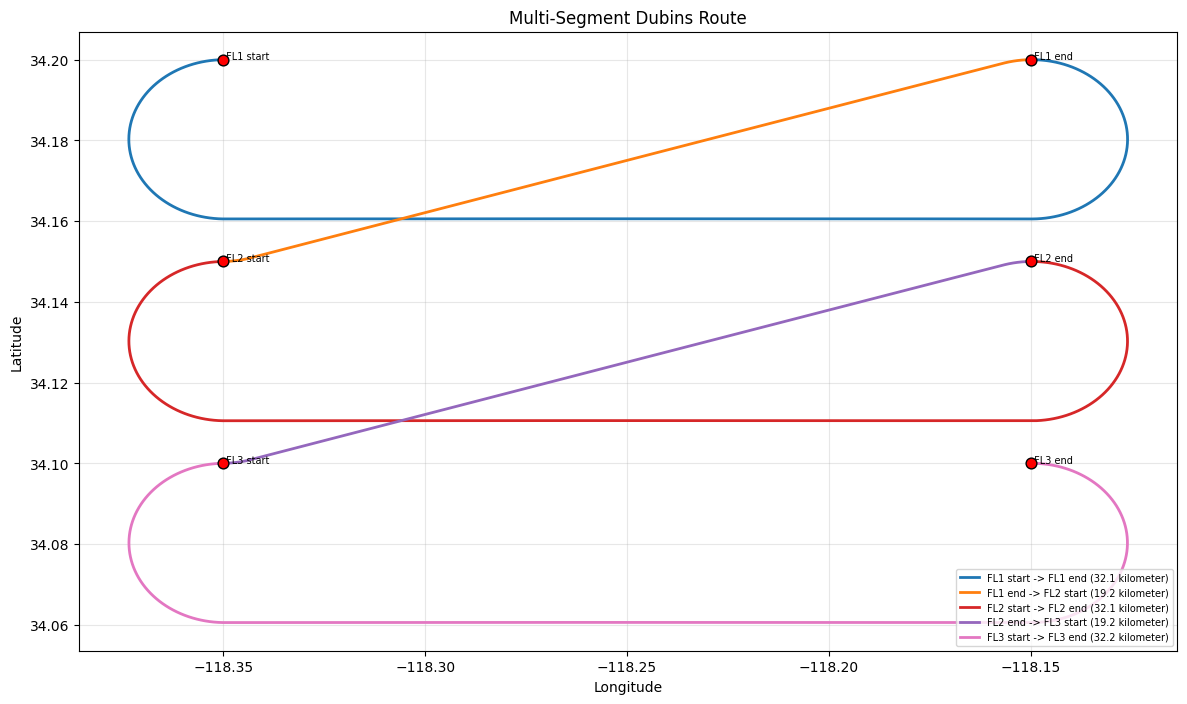

In [4]:
# Define a sequence of waypoints simulating flight line endpoints
waypoints = [
    Waypoint(34.20, -118.35, wrap_to_360(270.0), name="FL1 start"),
    Waypoint(34.20, -118.15, wrap_to_360(270.0), name="FL1 end"),
    Waypoint(34.15, -118.35, wrap_to_360(270.0), name="FL2 start"),
    Waypoint(34.15, -118.15, wrap_to_360(270.0), name="FL2 end"),
    Waypoint(34.10, -118.35, wrap_to_360(270.0), name="FL3 start"),
    Waypoint(34.10, -118.15, wrap_to_360(270.0), name="FL3 end"),
]

# Compute Dubins paths between consecutive waypoints
paths = []
total_distance = 0
for i in range(len(waypoints) - 1):
    dp = DubinsPath(waypoints[i], waypoints[i + 1], speed=100.0,
                    bank_angle=25.0, step_size=100.0)
    paths.append(dp)
    total_distance += dp.length.magnitude

print(f"Route: {len(paths)} segments, total distance: {total_distance:.0f} m "
      f"({total_distance / 1852:.1f} nmi)")

# Plot the route
fig, ax = plt.subplots(figsize=(12, 7))
colors = plt.cm.tab10(np.linspace(0, 0.6, len(paths)))

for i, (dp, color) in enumerate(zip(paths, colors)):
    lons, lats = zip(*list(dp.geometry.coords))
    label = f"{waypoints[i].name} -> {waypoints[i+1].name} ({dp.length.to('km'):.1f})"
    ax.plot(lons, lats, color=color, linewidth=2, label=label)

# Plot waypoints
for wp in waypoints:
    ax.scatter(wp.longitude, wp.latitude, c="red", s=60, zorder=5, edgecolors="black")
    ax.annotate(f" {wp.name}", (wp.longitude, wp.latitude), fontsize=7)

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Multi-Segment Dubins Route")
ax.legend(fontsize=7, loc="lower right")
ax.grid(True, alpha=0.3)
ax.set_aspect("equal")
plt.tight_layout()
plt.show()

## 4. Path Serialization

`DubinsPath.to_dict()` serializes the path for export, including start/end
coordinates, headings, altitudes, and total distance.

In [5]:
d = path.to_dict()
for key, val in d.items():
    if key != "geometry":
        print(f"  {key}: {val}")
print(f"  geometry: LineString with {len(list(path.geometry.coords))} points")

  start_lat: 34.2
  start_lon: -118.35
  end_lat: 34.1
  end_lon: -118.15
  start_altitude: None
  end_altitude: None
  start_heading: 90.0
  end_heading: 270.0
  distance: 14.254539741966541
  geometry: LineString with 265 points


## 5. Integration with Flight Lines

`FlightLine` objects expose `.waypoint1` and `.waypoint2` properties that return
`Waypoint` objects, making it easy to compute Dubins transitions between
flight lines.

FL1: Line 1, az=90 degree deg, length=30.0 kilometer
FL2: Line 2, az=270 degree deg, length=30.0 kilometer
Transition: 8.0 kilometer


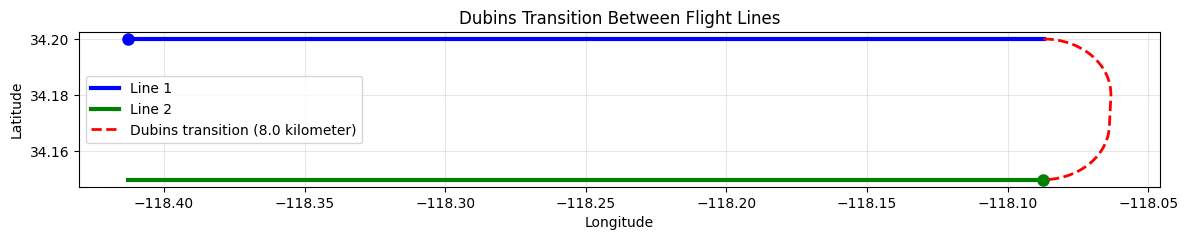

In [6]:
# Create two parallel flight lines
fl1 = FlightLine.center_length_azimuth(
    lat=34.20, lon=-118.25, length=ureg.Quantity(30, "km"),
    az=90.0, altitude_msl=ureg.Quantity(20000, "feet"), site_name="Line 1",
)
fl2 = FlightLine.center_length_azimuth(
    lat=34.15, lon=-118.25, length=ureg.Quantity(30, "km"),
    az=270.0, altitude_msl=ureg.Quantity(20000, "feet"), site_name="Line 2",
)

# Dubins path from end of FL1 to start of FL2
transition = DubinsPath(
    start=fl1.waypoint2,  # End of flight line 1
    end=fl2.waypoint1,    # Start of flight line 2
    speed=100.0,
    bank_angle=25.0,
    step_size=100.0,
)

print(f"FL1: {fl1.site_name}, az={fl1.az12:.0f} deg, length={fl1.length.to('km'):.1f}")
print(f"FL2: {fl2.site_name}, az={fl2.az12:.0f} deg, length={fl2.length.to('km'):.1f}")
print(f"Transition: {transition.length.to('km'):.1f}")

fig, ax = plt.subplots(figsize=(12, 6))

# Flight lines
for fl, color in [(fl1, "blue"), (fl2, "green")]:
    coords = list(fl.geometry.coords)
    x, y = zip(*coords)
    ax.plot(x, y, color=color, linewidth=3, label=fl.site_name)
    ax.plot(x[0], y[0], "o", color=color, markersize=8)  # start

# Transition path
lons, lats = zip(*list(transition.geometry.coords))
ax.plot(lons, lats, "r--", linewidth=2, label=f"Dubins transition ({transition.length.to('km'):.1f})")

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Dubins Transition Between Flight Lines")
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_aspect("equal")
plt.tight_layout()
plt.show()

## 6. Effect of Speed and Bank Angle

Higher speed or shallower bank angle increases the turn radius, requiring
more space for turns. This directly affects how much time is spent
maneuvering between flight lines.

In [7]:
# Compare turn radii
print("Turn radius (meters) for various speed/bank combinations:\n")
print(f"{'Speed (m/s)':<15} {'Bank 15 deg':<15} {'Bank 25 deg':<15} {'Bank 30 deg':<15} {'Bank 35 deg':<15}")
for v in [60, 80, 100, 120, 150, 200]:
    radii = []
    for ba in [15, 25, 30, 35]:
        r = v**2 / (9.8 * np.tan(np.radians(ba)))
        radii.append(f"{r:.0f}")
    print(f"{v:<15} {'  '.join(f'{r:<13}' for r in radii)}")

Turn radius (meters) for various speed/bank combinations:

Speed (m/s)     Bank 15 deg     Bank 25 deg     Bank 30 deg     Bank 35 deg    
60              1371           788            636            525          
80              2437           1400           1131           933          
100             3808           2188           1767           1457         
120             5484           3151           2545           2099         
150             8568           4924           3977           3279         
200             15233          8753           7070           5829         


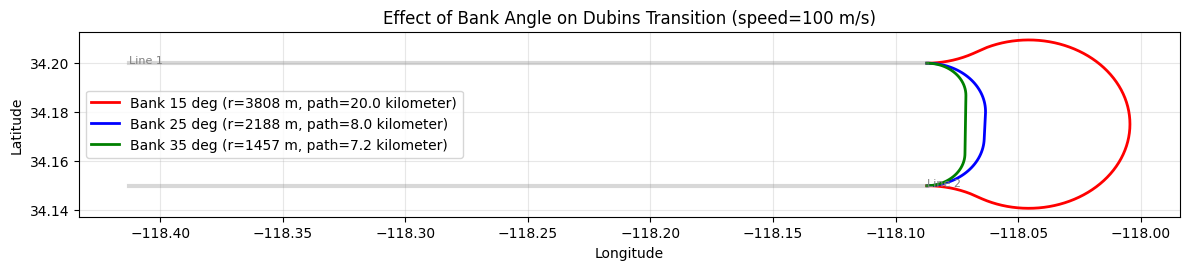

In [8]:
# Visualize the same transition at different bank angles
fig, ax = plt.subplots(figsize=(12, 7))

bank_angles = [15, 25, 35]
colors = ["red", "blue", "green"]

for ba, color in zip(bank_angles, colors):
    dp = DubinsPath(fl1.waypoint2, fl2.waypoint1, speed=100.0,
                    bank_angle=ba, step_size=100.0)
    r = 100.0**2 / (9.8 * np.tan(np.radians(ba)))
    lons, lats = zip(*list(dp.geometry.coords))
    ax.plot(lons, lats, color=color, linewidth=2,
            label=f"Bank {ba} deg (r={r:.0f} m, path={dp.length.to('km'):.1f})")

# Flight lines for context
for fl, c in [(fl1, "gray"), (fl2, "gray")]:
    x, y = zip(*fl.geometry.coords)
    ax.plot(x, y, color=c, linewidth=3, alpha=0.3)
    ax.annotate(fl.site_name, (x[0], y[0]), fontsize=8, color="gray")

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Effect of Bank Angle on Dubins Transition (speed=100 m/s)")
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_aspect("equal")
plt.tight_layout()
plt.show()

## 7. Closed-Loop Route

Dubins paths can model a complete closed-loop mission, returning the aircraft
to its starting waypoint.

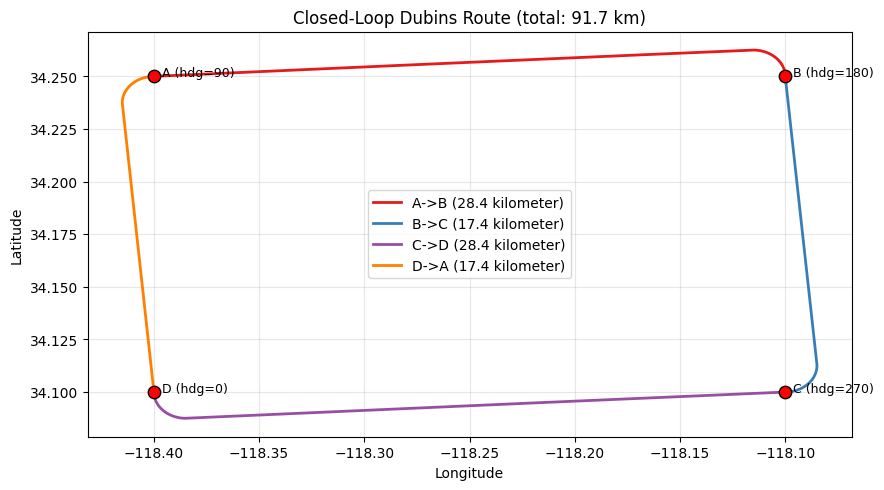

In [9]:
# Closed-loop route through 4 waypoints
loop_wps = [
    Waypoint(34.25, -118.40, 90.0, name="A"),
    Waypoint(34.25, -118.10, 180.0, name="B"),
    Waypoint(34.10, -118.10, 270.0, name="C"),
    Waypoint(34.10, -118.40, 0.0, name="D"),
    Waypoint(34.25, -118.40, 90.0, name="A"),  # Return to start
]

fig, ax = plt.subplots(figsize=(9, 8))
colors = plt.cm.Set1(np.linspace(0, 0.5, len(loop_wps) - 1))

total_dist = 0
for i in range(len(loop_wps) - 1):
    dp = DubinsPath(loop_wps[i], loop_wps[i + 1], speed=80.0,
                    bank_angle=25.0, step_size=50.0)
    lons, lats = zip(*list(dp.geometry.coords))
    ax.plot(lons, lats, color=colors[i], linewidth=2,
            label=f"{loop_wps[i].name}->{loop_wps[i+1].name} ({dp.length.to('km'):.1f})")
    total_dist += dp.length.magnitude

for wp in loop_wps[:-1]:
    ax.scatter(wp.longitude, wp.latitude, c="red", s=80, zorder=5, edgecolors="black")
    ax.annotate(f"  {wp.name} (hdg={wp.heading:.0f})", (wp.longitude, wp.latitude), fontsize=9)

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title(f"Closed-Loop Dubins Route (total: {total_dist/1000:.1f} km)")
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_aspect("equal")
plt.tight_layout()
plt.show()

## Summary

| Class | Purpose |
|-------|---------|
| `Waypoint(lat, lon, heading, altitude_msl, name)` | Oriented position for path planning |
| `DubinsPath(start, end, speed, bank_angle, step_size)` | Shortest curved path between two waypoints |

| Property/Method | Description |
|-----------------|-------------|
| `Waypoint.geometry` | Shapely Point |
| `Waypoint.to_dict()` | Dictionary serialization |
| `DubinsPath.geometry` | LineString of the computed path |
| `DubinsPath.length` | Total path length (Pint Quantity) |
| `DubinsPath.to_dict()` | Dictionary with coordinates, headings, distance |
| `FlightLine.waypoint1` / `.waypoint2` | Extract waypoints from flight line endpoints |

**Key relationships:**
- Turn radius = $v^2 / (g \cdot \tan(\theta))$ — determined by speed and bank angle
- Higher speed or shallower bank = larger turns = longer transitions
- `FlightLine` waypoints integrate directly with `DubinsPath` for route planning